
$$
\Large{\textbf{
  Polutant dispersion: deterministic and stochastic models
  }}
$$
\
$$
\large{\text{
  Johannes Löppönen, Arvid Hedin, Elis Graipe
  }}
$$
$$
\ \\
\ \\
\ \\
\ \\
\ \\
$$

# Introduction


This project aims to model the dispersion of pollutant particles in air, from combustion. The dispersion can be described using a partial differental equation but in this project the dispersion will be modeled using a stochastic simulation utilizing a random walk for each polutant particle using Brownian motion. Brownian motion is typpically used to describes how particles move in a liquid and is therefore well suited to modelling pollutant particles in air because air behaves like a liquid.


# Approach and method

In this section, you summarise your approach to the problem, and/or the method(s) you've used. Explain briefly the algorithm(s) you have chosen to use. Also explain why these algorithms are appropriate in this context. In this section, you may also show snippets of code (or pseudo code or algorithms). However, the complete code should not be inserted here, but in an Appendix.
If the project consists of several parts, it is usually a good idea that the section has subsections for each part.

You may need to add some mathematical formulas, for example:

Assume that $\textbf y = [y_1,y_2] = [F,R]$ is the state vector, and specify the propensity functions and state-change vectors as below:
$$
\begin{array}{llll}
1.& R \xrightarrow{\alpha} 2R      & v_1 = [0,1],  & w_1 = \alpha y_2\\
2.& R+F\xrightarrow{\beta} 2F      & v_2 = [1,-1], & w_2 = \beta y_1y_2\\
3.& F\xrightarrow{\gamma}\emptyset & v_3 = [-1,0], & w_3 = \gamma y_1
\end{array}
$$

We also assume $a = w_1+w_2+w_3$ and $p_j = \frac{w_j}{a}$ for $j=1,2,3$. Here, $p_j$ is the probability of reaction $j$ to happen. The state-change matrix is defined as

$$
S =
\begin{bmatrix}
0 & 1 \\
1 & -1 \\
-1 & 0
\end{bmatrix}.
$$

The corresponding ODE is
\begin{align*}
&\frac{dF}{dt} = \beta FR - \gamma F \\
&\frac{dR}{dt} = \alpha R -\beta FR
\end{align*}

You may need to add some code snippets, for example:

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Constants

N = 2000         
T = 60       
h = 0.1         
D = 0.02
epsilon = 0.1

u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

# Task 1

In [12]:
def euler(N, T, h, D, u, num_steps, checkpoints, q):
    X = np.zeros((N, 2))
    particles_per_step = int(q * h) 
    t = np.linspace(0, T, num_steps + 1)

    snapshots = []

    for n in range(num_steps + 1):
        new_particles = np.zeros((particles_per_step, 2))
        X = np.vstack([X, new_particles])
        
        num_active = X.shape[0]
        Z = np.random.randn(num_active, 2)
        X = X + u * h + np.sqrt(2 * D * h) * Z        
        
        if any(np.isclose(t[n], checkpoints)):
            snapshots.append(X.copy())

    return snapshots

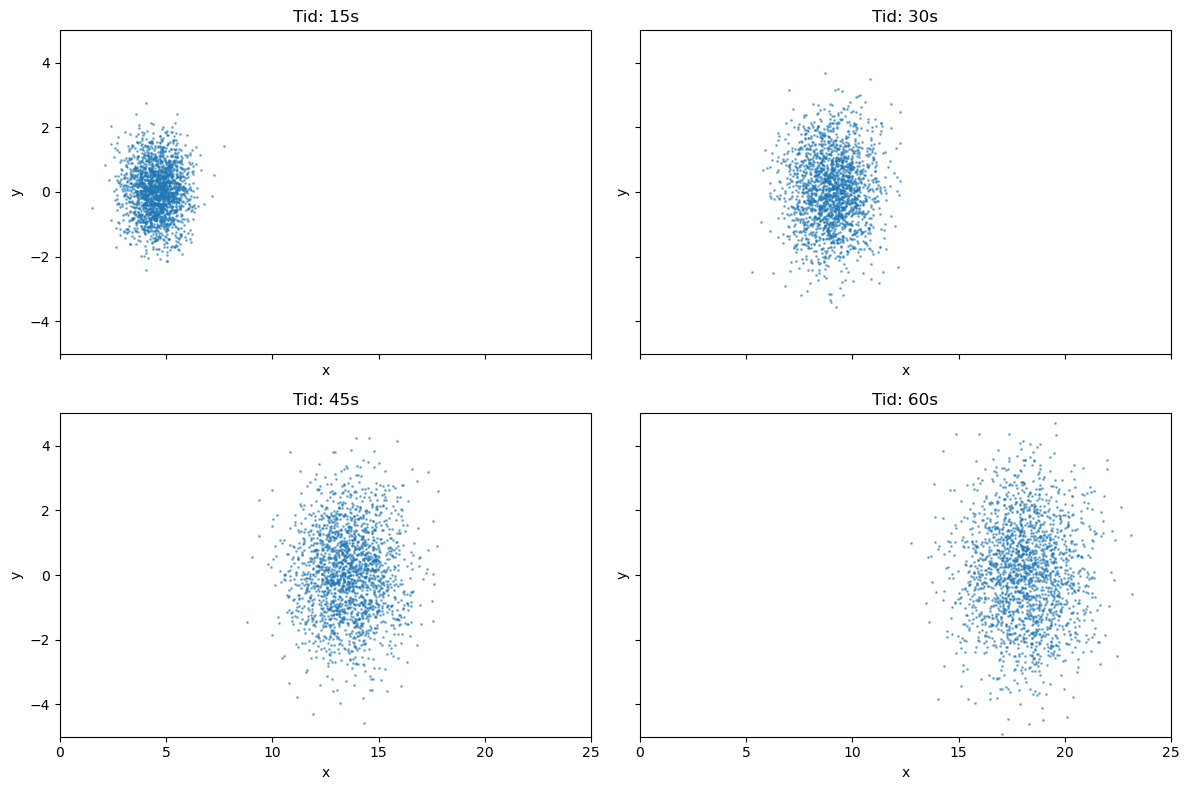

In [13]:
# Plot

snapshots = euler(N,T,h,D,u,num_steps, checkpoints, 0) # No source term
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

# Task 2

In [14]:
def delta_eps(dist, epsilon):
    fac = 1/(2*np.pi*epsilon**2)
    e = np.exp(-dist / (2*epsilon**2))
    return fac * e

def compute_concentration(x_grid, y_grid, snapshot, epsilon):
    N = snapshot.shape[0] #Antalet partiklar vid tiden t
    C = np.zeros(x_grid.shape)

    for k in range(N):
        dist = ((x_grid - snapshot[k,0])**2 + (y_grid - snapshot[k,1])**2)
        C += delta_eps(dist, epsilon)

    return C / N

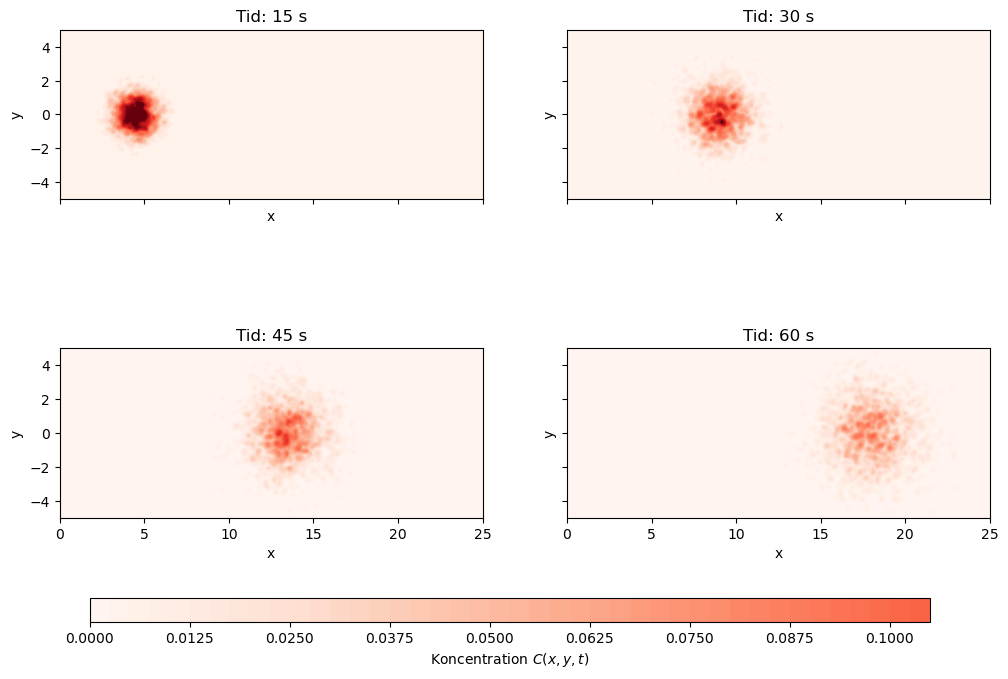

In [15]:
# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.2

# Run the simulation from task 1
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,0)

for i in range(len(snapshots)):
    X = snapshots[i]
    C = compute_concentration(x_grid, y_grid, X, epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=50, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_aspect('equal')
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Koncentration $C(x,y,t)$')

plt.show()

# Task 3

Paragraf efter rubrik

## a

In [16]:
# Constants
N = 0         
T = 60       
h = 0.1         
D = 0.02     
Q = 100    
u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

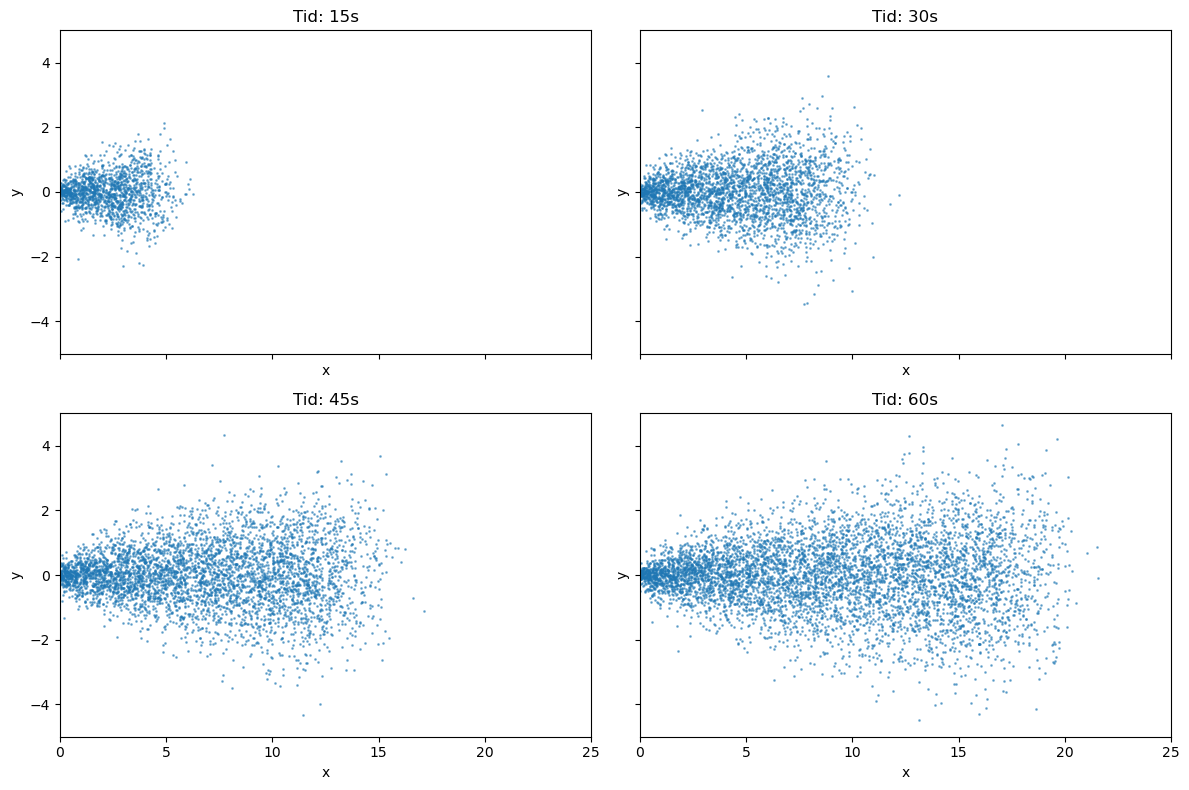

In [17]:
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,Q)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

## b

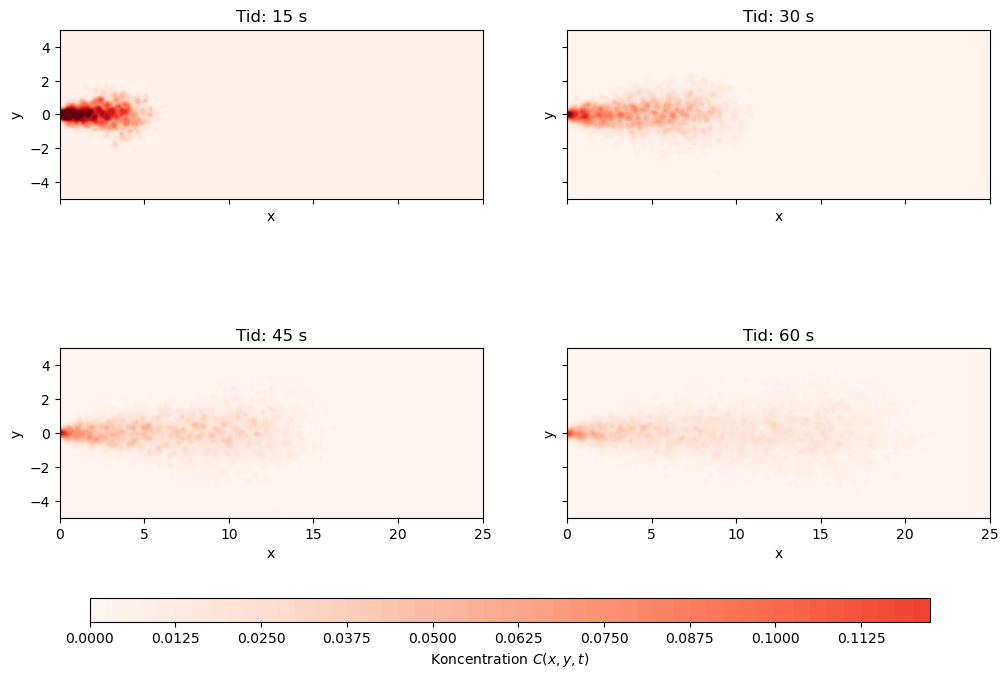

In [18]:
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,Q)

# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.2

for i in range(len(snapshots)):
    C = compute_concentration(x_grid, y_grid, snapshots[i], epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=50, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_aspect('equal')
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

fig.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Koncentration $C(x,y,t)$')

plt.show()

# Results

In this section, you report the results of each part of the project. To demonstrate that the program works as intended, you include examples of program execution. Present the results in a relevant and appropriate way, like figures, results on the screen etc. If the results contain too much, for example a long list of numbers displayed on the screen, it's recommended to cut it off (and be clear about it in the description). You might also consider making a plot instead of presenting the numbers.
It is important that you convince the reader that you have been able to carry out the mini-project according to the requirements in the mini-project description. You can of course do more than required if you feel it's relevant.



You may plot your necessary figures by executing your code snippets.

Always use `plt.show()` to hide unnecessary output numbers in plt plots. 

# Discussion


In this section you place the additional comments that you find relevant to make, for example, things you might have thought about, things that are unclear, things that would interesting to continue with etc. Some of the mini-projects explicitly contain issues to discuss, and these questions can be addressed in this section.


# References
Here you should include a list of the literature that you use or quote in the report.



# Appendix (if necessary)


Include extended code in an appendix, if any. It might also be other things that do not really fit in the main text that can be included in appendices. For example, it's quite common to see full results in the appendix, and just a few of them in the main text (or just a reference to the appendix in the main text).
